# Advanced Visualisation

```{admonition} Overview
:class: info

In this chapter, we move beyond basic maps and use visualisation to support interpretation.

Advanced visualisations help us:

- classify continuous values into meaningful groups
- highlight important cities or high-benefit areas
- compare spatial patterns more clearly
- communicate results for planning and decision-making

---

**Learning goals**

By the end of this chapter, you will be able to:

- prepare reusable map elements
- create binned choropleth maps
- highlight high-benefit areas
- classify cities into benefit groups
- identify top-performing cities
- add titles, borders, labels, and source captions
```

```{admonition} What Is Spatial Data?
:class: tip, dropdown

Spatial data combines **information + location**.

Unlike ordinary tables, spatial data allows us to place information on a map and observe geographic patterns.

---

**Key ideas**

- Spatial data = **data + location**
- Tables show **what**
- Maps show **where**
- Geometry can represent:
  - points
  - lines
  - polygons

In this dataset, each city is represented by a polygon geometry, allowing us to map climate-regulation patterns across Germany.
```

```{admonition} Base Setup
:class: info, dropdown

This cell prepares shared objects that will be reused throughout the chapter.

It will:

- load the GeoPackage
- load country boundaries
- check required columns
- prepare labels for selected major city polygons
- define the map extent
- create reusable source-caption text
```

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import pandas as pd
import numpy as np
import matplotlib.patheffects as pe
from pathlib import Path

# -----------------------------
# Inputs
# -----------------------------

DATA_DIR = Path.cwd() / "data" / "raw"

data_path = DATA_DIR / "climate_regulation_in_cities.gpkg"

value_col = "Pop_Benefit_Percent"
name_col = "GEN"

N_LABELS = 15
BUFFER_FRAC = 0.25

# -----------------------------
# Output folder
# -----------------------------

fig_dir = Path.cwd() / "_static" / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    raise FileNotFoundError(
        f"GeoPackage not found:\n{data_path}\n\n"
        "Please complete the download step before continuing."
    )

# -----------------------------
# Load data
# -----------------------------

gdf = gpd.read_file(data_path)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# -----------------------------
# Safety checks
# -----------------------------

if value_col not in gdf.columns:
    raise ValueError(f"'{value_col}' not found. Available columns: {list(gdf.columns)}")

if name_col not in gdf.columns:
    raise ValueError(f"'{name_col}' not found. Available columns: {list(gdf.columns)}")

# -----------------------------
# Prepare data
# -----------------------------

gdf = gdf.copy()
gdf[value_col] = pd.to_numeric(gdf[value_col], errors="coerce")

world = world.to_crs(gdf.crs)

# -----------------------------
# Map extent
# -----------------------------

minx, miny, maxx, maxy = gdf.total_bounds
dx, dy = maxx - minx, maxy - miny

buffer_x = dx * BUFFER_FRAC
buffer_y = dy * BUFFER_FRAC

bbox_geom = box(
    minx - buffer_x,
    miny - buffer_y,
    maxx + buffer_x,
    maxy + buffer_y,
)

neighbors = world[world.intersects(bbox_geom)]

# -----------------------------
# Automatic city labels
# -----------------------------

labels_gdf = gdf[gdf[value_col].fillna(0) > 0].copy()
labels_gdf["_area_m2"] = labels_gdf.geometry.area
labels_gdf = labels_gdf.nlargest(N_LABELS, "_area_m2").copy()
label_pts = labels_gdf.representative_point()

# -----------------------------
# Reusable caption
# -----------------------------

caption = (
    "Source: IOER, Climate Regulation in Cities dataset. "
    "Indicator: population benefiting from cooling effect of urban green infrastructure. "
    "Administrative boundaries: Natural Earth. "
    "Map created for ioerDATA training."
)

print("Base map prepared.")
print("Number of cities:", len(gdf))
print("Available columns:", list(gdf.columns))
print("Automatically labelled cities:", labels_gdf[name_col].tolist())

Base map prepared.
Number of cities: 165
Available columns: ['AGS', 'GEN', 'NUTS', 'Shape_Leng', 'Shape_Area', 'Pop_Benefit_Percent', 'geometry']
Automatically labelled cities: ['Berlin', 'Hamburg', 'Köln', 'Dresden', 'Bremen', 'München', 'Münster', 'Leipzig', 'Dortmund', 'Erfurt', 'Bielefeld', 'Frankfurt am Main', 'Dessau-Roßlau', 'Duisburg', 'Brandenburg an der Havel']


```{admonition} Reusable Map Helper
:class: info, dropdown

To avoid repeating the same code in every map, we create a helper function.

This function adds:

- neighboring country borders
- city borders
- selected city labels
- map extent
- title
- source caption

This keeps the following visualisation code shorter and easier to read.
```

In [2]:
def add_map_context(ax, title=None):
    """Add shared cartographic context to a map axis."""
    
    # Neighboring country outlines
    neighbors.boundary.plot(
        ax=ax,
        linewidth=0.8,
        color="black",
        zorder=2
    )
    
    # City borders
    gdf.boundary.plot(
        ax=ax,
        linewidth=0.35,
        color="white",
        alpha=0.9,
        zorder=4
    )
    
    # Selected city labels with white halo
    for x, y, nm in zip(label_pts.x, label_pts.y, labels_gdf[name_col].astype(str)):
        txt = ax.text(
            x,
            y,
            nm,
            fontsize=8,
            ha="center",
            va="center",
            color="black",
            zorder=10
        )
        txt.set_path_effects([
            pe.withStroke(linewidth=3, foreground="white")
        ])
    
    # Map extent
    ax.set_xlim(minx - buffer_x, maxx + buffer_x)
    ax.set_ylim(miny - buffer_y, maxy + buffer_y)
    
    # Title
    if title:
        ax.set_title(
            title,
            fontsize=15,
            fontweight="bold",
            pad=12
        )
    
    # Caption below map
    ax.figure.subplots_adjust(bottom=0.12)
    ax.figure.text(
        0.5,
        0.03,
        caption,
        ha="center",
        va="bottom",
        fontsize=8,
        color="dimgray",
        wrap=True
    )
    
    ax.set_axis_off()

```{admonition} Advanced Visualisation 1: Binned Choropleth
:class: info, dropdown

A binned choropleth groups continuous values into classes.

Here, we use **quantiles**, which means each class contains roughly the same number of cities.

This is useful because it:

- simplifies continuous values
- makes differences easier to compare
- supports clearer interpretation
```

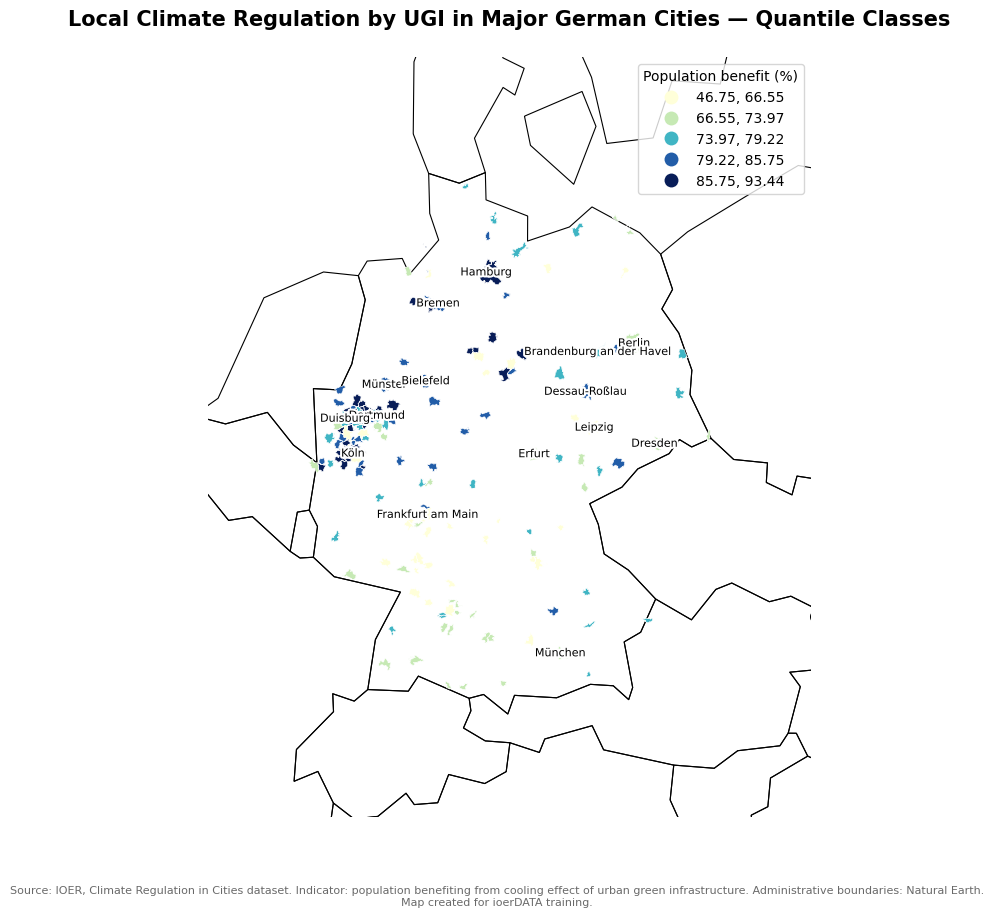

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column=value_col,
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="none",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    zorder=3
)

add_map_context(
    ax,
    title="Local Climate Regulation by UGI in Major German Cities — Quantile Classes"
)

legend = ax.get_legend()
if legend:
    legend.set_title("Population benefit (%)")

plt.show()

In [10]:
#| tags: [remove-input]

from pathlib import Path
from IPython.display import HTML, display

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "downloads"
download_dir.mkdir(parents=True, exist_ok=True)

png_name = "local_climate_regulation_ugi_major_german_cities_Quantile_Classes.png"
#pdf_name = "local_climate_regulation_ugi_major_german_cities_Quantile_Classes.pdf"

output1_png = download_dir / png_name
#output1_pdf = download_dir / pdf_name

fig.savefig(output1_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(HTML(f"""
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/downloads/{png_name}" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""))

```{admonition} Interpreting the Binned Choropleth
:class: tip, dropdown

This map helps compare cities by grouping them into relative classes.

---

**What to look for**

- Which cities fall into higher quantile groups?
- Are high values clustered in specific regions?
- Are there clear spatial differences across Germany?

---

**Important note**

Quantile classes are useful for comparison, but they do not show absolute thresholds such as “above 70%”.
```

```{admonition} Advanced Visualisation 2: Highlight High-Benefit Areas
:class: info, dropdown

In this map, we highlight cities where the population benefit is above a selected threshold.

This makes it easier to identify cities with especially strong climate-regulation benefits.
```

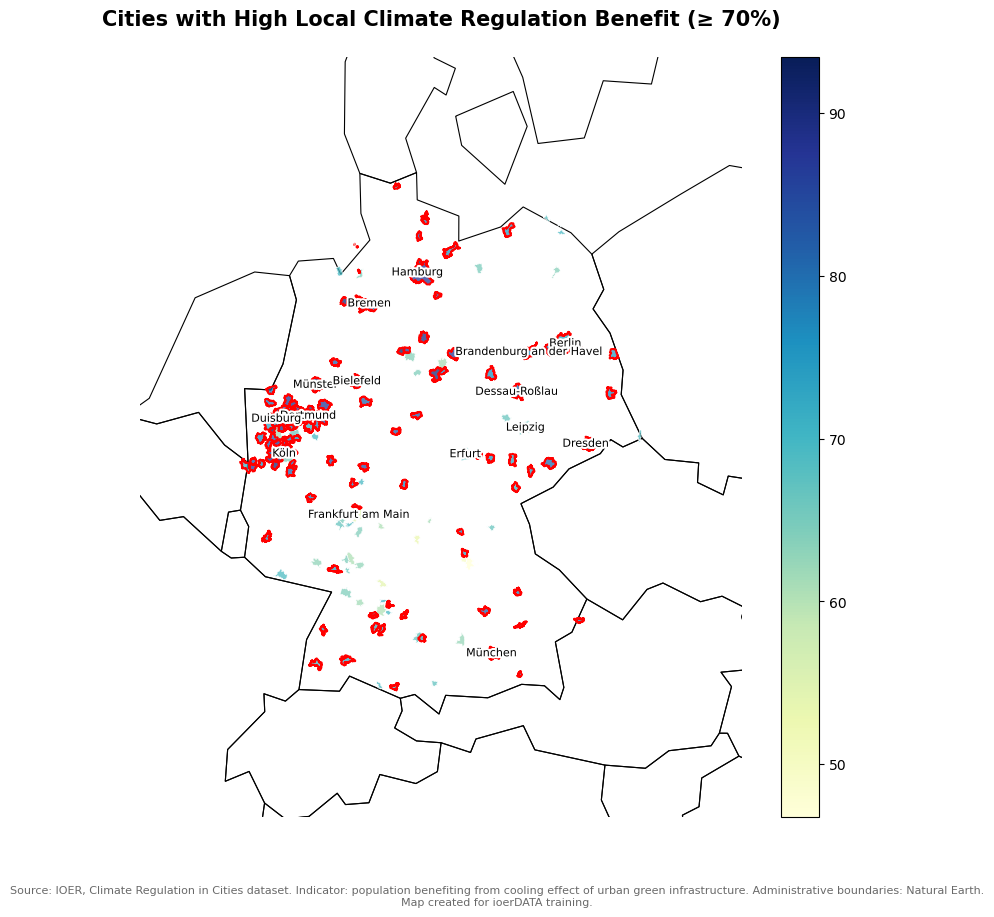

In [11]:
threshold = 70

high_benefit = gdf[gdf[value_col] >= threshold]

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column=value_col,
    cmap="YlGnBu",
    legend=True,
    edgecolor="none",
    alpha=0.75,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    zorder=3
)

high_benefit.boundary.plot(
    ax=ax,
    color="red",
    linewidth=1.4,
    zorder=6
)

add_map_context(
    ax,
    title=f"Cities with High Local Climate Regulation Benefit (≥ {threshold}%)"
)

plt.show()

In [13]:
#| tags: [remove-input]

from pathlib import Path
from IPython.display import HTML, display

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "downloads"
download_dir.mkdir(parents=True, exist_ok=True)

png_name = "Cities_with_High_Local_Climate_Regulation_Benefit.png"
#pdf_name = "Cities_with_High_Local_Climate_Regulation_Benefit.pdf"

output1_png = download_dir / png_name
#output1_pdf = download_dir / pdf_name

fig.savefig(output1_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(HTML(f"""
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/downloads/{png_name}" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""))

```{admonition} Interpreting the Highlighted Map
:class: tip, dropdown

The red outlines show cities where the indicator value is above the selected threshold.

---

**Why this is useful**

- The background map shows the full pattern
- The red outlines draw attention to high-benefit cities
- The threshold makes the interpretation more explicit

---

**Design note**

Thresholds should always be explained clearly because different threshold choices can change the message of the map.
```

```{admonition} Advanced Visualisation 3: Benefit Classes
:class: info, dropdown

Instead of using many values, we can classify cities into simple categories:

- **High benefit**
- **Medium benefit**
- **Low benefit**

This makes the map easier to interpret for non-technical audiences.
```

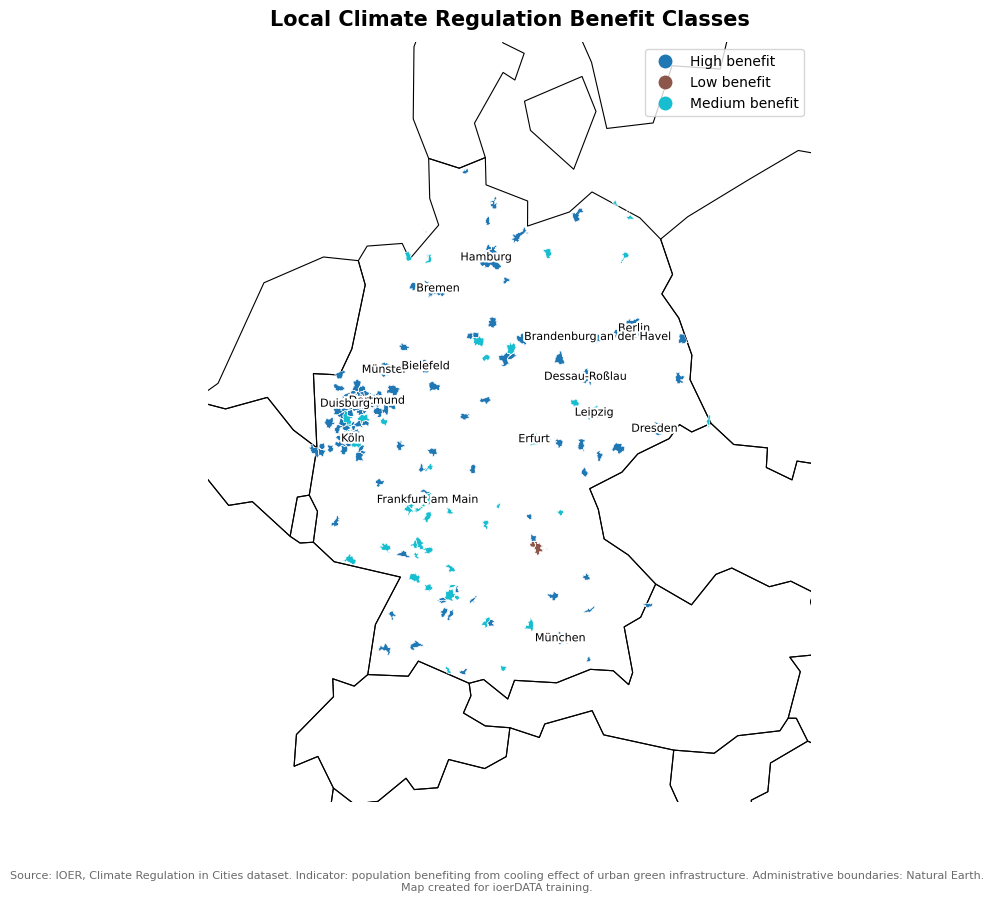

In [14]:
gdf_class = gdf.copy()

conditions = [
    gdf_class[value_col] >= 70,
    (gdf_class[value_col] >= 50) & (gdf_class[value_col] < 70),
    gdf_class[value_col] < 50
]

categories = [
    "High benefit",
    "Medium benefit",
    "Low benefit"
]

gdf_class["Benefit_Class"] = np.select(
    conditions,
    categories,
    default="Unknown"
)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_class.plot(
    column="Benefit_Class",
    categorical=True,
    legend=True,
    edgecolor="none",
    ax=ax,
    zorder=3
)

add_map_context(
    ax,
    title="Local Climate Regulation Benefit Classes"
)

plt.show()

In [16]:
#| tags: [remove-input]

from pathlib import Path
from IPython.display import HTML, display

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "downloads"
download_dir.mkdir(parents=True, exist_ok=True)

png_name = "Local_Climate_Regulation_Benefit_Classes.png"
#pdf_name = "Cities_with_High_Local_Climate_Regulation_Benefit.pdf"

output1_png = download_dir / png_name
#output1_pdf = download_dir / pdf_name

fig.savefig(output1_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(HTML(f"""
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/downloads/{png_name}" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""))

```{admonition} Interpreting Benefit Classes
:class: tip, dropdown

This map is easier to read because values are grouped into meaningful classes.

---

# What this helps with

- communicating results to broader audiences
- comparing areas quickly
- reducing visual complexity

---

# Important note

Classes simplify the data. This improves readability, but also hides some detail.
```

```{admonition} Advanced Visualisation 4: Top-Benefit Cities
:class: info, dropdown

This map highlights the cities with the highest values of the selected indicator.

It is useful when we want to focus on ranking and identify the strongest-performing urban areas.
```

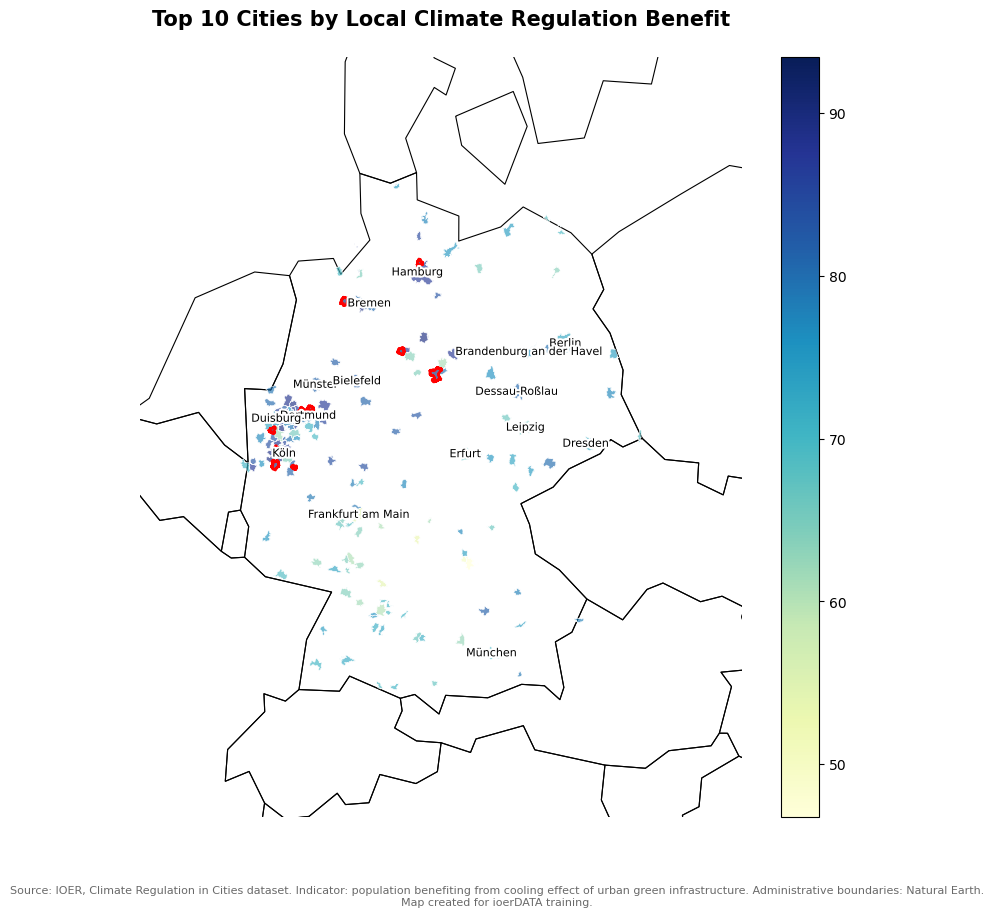

In [17]:
top_n = 10
top_cities = gdf.nlargest(top_n, value_col)

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column=value_col,
    cmap="YlGnBu",
    legend=True,
    edgecolor="none",
    alpha=0.65,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"},
    zorder=3
)

top_cities.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=1.8,
    zorder=6
)

add_map_context(
    ax,
    title=f"Top {top_n} Cities by Local Climate Regulation Benefit"
)

plt.show()

In [19]:
#| tags: [remove-input]

from pathlib import Path
from IPython.display import HTML, display

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "downloads"
download_dir.mkdir(parents=True, exist_ok=True)

png_name = "Top_Cities_by_Local_Climate_Regulation_Benefit.png"
#pdf_name = "Cities_with_High_Local_Climate_Regulation_Benefit.pdf"

output1_png = download_dir / png_name
#output1_pdf = download_dir / pdf_name

fig.savefig(output1_png, dpi=300, bbox_inches="tight")
#fig.savefig(output1_pdf, bbox_inches="tight")

display(HTML(f"""
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/downloads/{png_name}" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""))

```{admonition} Interpreting the Top-City Map
:class: tip, dropdown

This map highlights the cities with the highest population benefit values.

---

**What this helps answer**

- Which cities perform best?
- Where are the strongest climate-regulation benefits located?
- Are top-performing cities clustered or spread across Germany?

---

**Design note**

Ranking maps are useful, but they should not replace full-distribution maps.  
They show extremes, not the complete pattern.
```

```{admonition} Overall Takeaway
:class: tip, dropdown

Advanced visualisations are not necessarily more complicated.

They are more **purposeful**.

In this chapter, we used different visualisation strategies to answer different questions:

- **Binned choropleth** → How do cities compare relatively?
- **Highlighted areas** → Which cities exceed a chosen threshold?
- **Benefit classes** → How can we simplify interpretation?
- **Top-benefit cities** → Which cities perform strongest?

---

**Key message**

Effective maps combine:

- clear analytical purpose
- readable design
- geographic context
- transparent source information

These skills are especially important in urban climate research, where maps can support planning, communication, and policy decisions.
```